## Task purpose and Description

Company has recently launched eSIM service for two mobile apps on ANDROID and iOS phones.  
It offers mobile data to popular destinations where customer can choose a plan based on their data needs for the holiday.

Task is to evaluate the performance of each platform over the last few weeks.  
Keep in mind that not all Android devices support eSIM (due to compatibility issues), and customers are informed of this before making a purchase.

- Some guiding questions:
  - Calculate the conversion rate (CR) and any other relevant metrics. Do you notice any anomalies? If so, can you investigate what might have caused them?
  - Create a purchase funnel using the event data.
  - Provide any recommendations based on your analysis of the performance.
  - Consider any additional data that could provide further insights.


### Imports + load data


`sessions`  
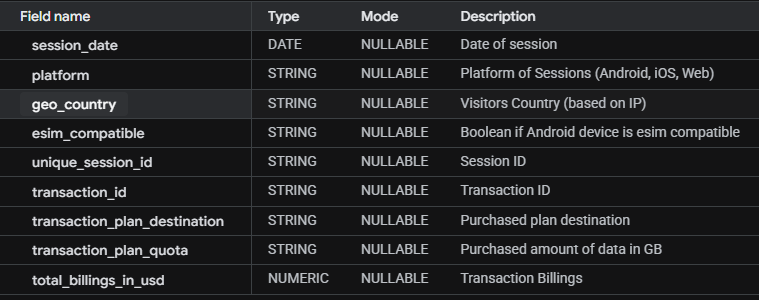

`events`  
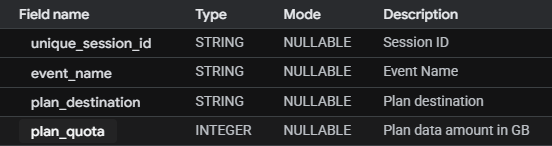


In [20]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

DATA_DIR = Path("./data")
sessions_path = DATA_DIR / "sessions.csv"
events_path = DATA_DIR / "events.csv"

if not sessions_path.exists():
    sessions_path = Path("sessions.csv")
if not events_path.exists():
    events_path = Path("events.csv")

sessions = pd.read_csv(sessions_path, parse_dates=["session_date"])
events = pd.read_csv(events_path)

display(sessions.head(1)), display(events.head(1))

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
0,2024-08-01,ANDROID,Tunisia,true,1722530830-9c47c790289045bf156fe4e25a60e3a7,NaN,NaN,NaN,0.0000


,unique_session_id,event_name,plan_destination,plan_quota
0,1724145563-26F74962FC3C4ABA829693247D77E175,click_to_order_1,AD,NaN


(None, None)

Register tables in DuckDB


In [21]:
con = duckdb.connect()

con.register("sessions", sessions)
con.register("events", events)

### Basic data scan

Getting familiar with the data, structure, dataset size, null values, uniqueness, duplicates, relationships, top/bottom values, anomalies, and patterns.

`sessions`: rows/columns `(274695, 9)`

- Null values are present.
- Date range is 2024-08-01 to 2024-08-27.
- Top country by user IP: United States.
- Top platform: iOS.
- Most frequent `unique_session_id` appears 22 times.
- `transaction_id` values are unique when present.
- Most frequent `transaction_plan_destination`: United States.

`events`: rows/columns `(252450, 4)`

- Null values are present.
- The most active session has 172 event rows.
- Most frequent `event_name`: `click_to_order_1`.
- Most frequent `plan_destination`: US.

Important early observation: `unique_session_id` is not unique across the full sessions table, so I need to be careful with the analysis grain.

Dominant platform is iOS. The dataset covers approximately one month.


In [22]:
print("sessions:", sessions.shape)
print("events:", events.shape)

display(sessions.info())
display(events.info())

# display(sessions.head())
# display(events.head())

sessions: (274695, 9)
events: (252450, 4)
<class 'pandas.DataFrame'>
RangeIndex: 274695 entries, 0 to 274694
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   session_date                  274695 non-null  datetime64[us]
 1   platform                      274695 non-null  str           
 2   geo_country                   274695 non-null  str           
 3   esim_compatible               274695 non-null  str           
 4   unique_session_id             274695 non-null  str           
 5   transaction_id                25133 non-null   str           
 6   transaction_plan_destination  25133 non-null   str           
 7   transaction_plan_quota        25133 non-null   float64       
 8   total_billings_in_usd         274695 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 18.9 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 252450 entries, 0 to 252449
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   unique_session_id  252450 non-null  str    
 1   event_name         252450 non-null  str    
 2   plan_destination   252449 non-null  str    
 3   plan_quota         82013 non-null   float64
dtypes: float64(1), str(3)
memory usage: 7.7 MB


None

In [23]:
display(sessions.describe(include="all"))
display(events.describe(include="all"))

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
count,274695,274695,274695,274695,274695,25133,25133,"25,133.0000","274,695.0000"
unique,NaN,2,42,3,241548,25133,155,NaN,NaN
top,NaN,IOS,United States,not_applicable,1720967885-721d01f8cfec84a9b964c66287048e91,582be001-336a-4d32-bb88-90a828120b71,US,NaN,NaN
freq,NaN,147224,81278,147224,22,1,6875,NaN,NaN
mean,2024-08-14 17:42:34.421449,NaN,NaN,NaN,NaN,NaN,NaN,6.7398,1.3055
min,2024-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.0000
25%,2024-08-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,3.0000,0.0000
50%,2024-08-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,5.0000,0.0000
75%,2024-08-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.0000,0.0000
max,2024-08-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,179.9900


,unique_session_id,event_name,plan_destination,plan_quota
count,252450,252450,252449,"82,013.0000"
unique,115996,2,178,NaN
top,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,US,NaN
freq,172,170437,47520,NaN
mean,NaN,NaN,NaN,5.6285
std,NaN,NaN,NaN,6.8161
min,NaN,NaN,NaN,1.0000
25%,NaN,NaN,NaN,1.0000
50%,NaN,NaN,NaN,3.0000
75%,NaN,NaN,NaN,10.0000


Checking the most frequent session.

Noticed session with highest frequency in the events table:

- `1724723941-85d9250152d7174971df6119269db913`

One specific session has 172 event rows.  
The user clicked many different destinations, reached `click_to_order_2` only for 5 destinations, all with 1 GB, but never made a purchase.

This does not look like a normal customer journey. It looks more like one of the following:

- heavy browsing;
- comparison behavior;
- possible bot/test/internal QA behavior;
- tracking duplication.

Because of these extreme event counts, I avoid using raw event counts directly in the funnel.  
Instead, I convert events into session-level flags: whether a session reached `click_to_order_1`, whether it reached `click_to_order_2`, and whether it purchased.  
This prevents a small number of abnormal high-activity sessions from overweighting the funnel.


In [24]:
query = """
SELECT
    *
FROM sessions
where unique_session_id in ('1724723941-85d9250152d7174971df6119269db913')
order by unique_session_id, session_date
"""
display(con.execute(query).df())

query = """
SELECT
    *
FROM events
where unique_session_id in ('1724723941-85d9250152d7174971df6119269db913')
order by unique_session_id, event_name
"""
display(con.execute(query).df())

query = """
SELECT
    count(DISTINCT plan_destination) AS unique_plan_destinations,
    event_name,
    plan_quota
FROM events
where unique_session_id in ('1724723941-85d9250152d7174971df6119269db913')
group by event_name, plan_quota
order by event_name
"""
display(con.execute(query).df())

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
0,2024-08-27,ANDROID,Morocco,true,1724723941-85d9250152d7174971df6119269db913,None,None,NaN,0.0000


,unique_session_id,event_name,plan_destination,plan_quota
0,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AE,NaN
1,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,ME,NaN
2,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AI,NaN
3,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AL,NaN
4,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AM,NaN
...,...,...,...,...
167,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,CZ,1.0000
168,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,MA,1.0000
169,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,TH,1.0000
170,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,TR,1.0000


,unique_plan_destinations,event_name,plan_quota
0,167,click_to_order_1,NaN
1,5,click_to_order_2,1.0000


### Check table grain

- sessions
- events

`sessions` - is not perfectly one row per session.  
`events` - is event-level and has many rows per session.


In [25]:
query = """
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids,
    COUNT(*) - COUNT(DISTINCT unique_session_id) AS duplicated_session_rows
FROM sessions
"""

con.execute(query).df()

,rows,unique_session_ids,duplicated_session_rows
0,274695,241548,33147


In [26]:
query = """
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids,
    COUNT(*) - COUNT(DISTINCT unique_session_id) AS extra_event_rows
FROM events
"""

con.execute(query).df()

,rows,unique_session_ids,extra_event_rows
0,252450,115996,136454


If this query returns 0 rows, then those fields are stable at that grain.


In [27]:
query = """
SELECT
    session_date,
    unique_session_id,
    COUNT(*) AS rows_in_group,
    COUNT(DISTINCT COALESCE(platform, '__NULL__')) AS platform_values,
    COUNT(DISTINCT COALESCE(geo_country, '__NULL__')) AS geo_country_values,
    COUNT(DISTINCT COALESCE(esim_compatible, '__NULL__')) AS esim_compatible_values
FROM sessions
GROUP BY
    session_date,
    unique_session_id
HAVING
    platform_values > 1
    OR geo_country_values > 1
    OR esim_compatible_values > 1
ORDER BY rows_in_group DESC
"""
grain_check = con.execute(query).df()
display(grain_check)

assert (
    grain_check.shape[0] == 0
), "Conflict found: session attributes are not stable within session_date + unique_session_id"

,session_date,unique_session_id,rows_in_group,platform_values,geo_country_values,esim_compatible_values


### Extra grain check for funnel safety

The daily analysis uses `session_date + unique_session_id`, but the funnel uses period-level event flags by `unique_session_id`.  
Before doing that join, I check whether `platform`, `geo_country`, and `esim_compatible` stay stable for the same `unique_session_id` across the full period.

If this returns rows, the funnel attribution would need to be redesigned.


In [28]:
# Safety check before using unique_session_id-level event flags in the funnel.
query = """
SELECT
    unique_session_id,
    COUNT(DISTINCT COALESCE(platform, '__NULL__')) AS platform_values,
    COUNT(DISTINCT COALESCE(geo_country, '__NULL__')) AS geo_country_values,
    COUNT(DISTINCT COALESCE(esim_compatible, '__NULL__')) AS compatibility_values,
    COUNT(DISTINCT session_date) AS active_dates
FROM sessions
GROUP BY unique_session_id
HAVING
    platform_values > 1
    OR geo_country_values > 1
    OR compatibility_values > 1
ORDER BY active_dates DESC
"""

session_id_stability_check = con.execute(query).df()
display(session_id_stability_check)

assert (
    session_id_stability_check.shape[0] == 0
), "Conflict found: session attributes are not stable within unique_session_id across the period"

,unique_session_id,platform_values,geo_country_values,compatibility_values,active_dates


### Check platforms and eSIM compatibility


In [29]:
query = """
SELECT
    platform,
    esim_compatible,
    COUNT(*) AS rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids
FROM sessions
GROUP BY platform, esim_compatible
ORDER BY rows DESC
"""

con.execute(query).df()

,platform,esim_compatible,rows,unique_session_ids
0,IOS,not_applicable,147224,128872
1,ANDROID,true,98510,85603
2,ANDROID,false,28961,27073


### Check transaction logic


sessions table has unique_transactions records that are not duplicated.  
It means that each row is actually unique but can belong to the same unique_session_id.


In [30]:
query = """
SELECT
    COUNT(*) AS rows,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,
    SUM(total_billings_in_usd) AS total_revenue
FROM sessions

"""

con.execute(query).df()

,rows,transaction_rows,unique_transactions,total_revenue
0,274695,25133,25133,"358,625.8500"


In [31]:
query = """
SELECT
    COUNT(DISTINCT transaction_id) AS unique_transactions
FROM sessions
"""

con.execute(query).df()

,unique_transactions
0,25133


In [32]:
query = """
SELECT
    COUNT( transaction_id) AS transactions
FROM sessions
where transaction_id IS NOT NULL
"""

con.execute(query).df()

,transactions
0,25133


Lookup and inspect most active sessions during time period.


In [33]:
query = """
SELECT
    unique_session_id,
    COUNT(DISTINCT session_date) AS active_dates
FROM sessions
GROUP BY unique_session_id
HAVING active_dates > 1
ORDER BY active_dates DESC
"""

con.execute(query).df().head()

,unique_session_id,active_dates
0,1720967885-721d01f8cfec84a9b964c66287048e91,22
1,1722804049-ffe27d1b30fc0f74fcfe1626b7eafa01,18
2,1723555581-a7b4d338bdb398cdbbc7218309323b78,14
3,1722696892-48938d4ffb2725cc714c9d5ace87f6d7,14
4,1723650130-50765428ce5d603a677d19104b5db6d3,14


Some identifiers appear in the sessions table across multiple dates but do not appear in the events table.  
This suggests that the sessions table is the base visitor/session activity table, while the events table only records specific purchase-funnel events.  
Therefore, users without event records should remain in the denominator when calculating funnel entry rates.


In [34]:
query = """
SELECT
   *
FROM sessions
where unique_session_id = '1720967885-721d01f8cfec84a9b964c66287048e91'
"""

con.execute(query).df()

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
0,2024-08-01,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
1,2024-08-03,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
2,2024-08-04,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
3,2024-08-05,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
4,2024-08-06,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
5,2024-08-08,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
6,2024-08-09,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
7,2024-08-10,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
8,2024-08-11,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
9,2024-08-12,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000


In [35]:
query = """
SELECT
   *
FROM events
where unique_session_id = '1720967885-721d01f8cfec84a9b964c66287048e91'
"""

con.execute(query).df()

,unique_session_id,event_name,plan_destination,plan_quota


The sessions table appears to represent daily visitor/session activity, not actual post-purchase eSIM usage. The `geo_country` field describes the visitor's country based on IP, while `transaction_plan_destination` describes the destination of the purchased eSIM plan.

Although the column is named `unique_session_id`, the same identifier can appear across multiple dates. Therefore, I treat `session_date + unique_session_id` as the main analysis grain for daily platform performance.

#### Metric definitions

- Analysis grain: one row = one `session_date + unique_session_id` context.
- Purchase: non-null `transaction_id` in the sessions table.
- Conversion rate: session-days with purchase / total session-days.
- Revenue per session-day: total revenue / total session-days.
- Revenue per buyer: total revenue / purchasing session-days.
- Funnel analysis is period-level because the events table has no event timestamp or `session_date`.

Purchases are identified using non-null `transaction_id` values in the sessions table. The events table is used to reconstruct funnel behavior before purchase, mainly through `click_to_order_1` and `click_to_order_2`.


#### 1. Creating a `session_day` table. It is a metric table where one row means one visitor/session-day context.


In [36]:
query = """
SELECT
    session_date,
    unique_session_id,
    platform,
    geo_country,
    esim_compatible,
    COUNT(*) AS source_rows,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,
    CASE
        WHEN COUNT(transaction_id) > 0 THEN 1
        ELSE 0
    END AS has_purchase,
    SUM(COALESCE(total_billings_in_usd, 0)) AS revenue
FROM sessions
GROUP BY
    session_date,
    unique_session_id,
    platform,
    geo_country,
    esim_compatible
"""

session_day = con.execute(query).df()
con.register("session_day", session_day)
session_day

,session_date,unique_session_id,platform,geo_country,esim_compatible,source_rows,transaction_rows,unique_transactions,has_purchase,revenue
0,2024-08-22,1724357945-e50da2777bd319d3bf3b11a94e2d4bce,ANDROID,Poland,true,1,0,0,0,0.0000
1,2024-08-22,1724302048-f85c5478f2147612945291dfb91e83fb,ANDROID,Canada,true,1,0,0,0,0.0000
2,2024-08-22,1724301147-57d5c1dbf287b5ec22bea398f73cca31,ANDROID,Canada,true,2,1,1,1,5.2900
3,2024-08-22,1724321236-cea90bda5d550fd1d73bde0dec4fe627,ANDROID,Poland,true,1,0,0,0,0.0000
4,2024-08-22,1724314048-33672daec869f5ae6a6c56149865907c,ANDROID,United States,true,2,1,1,1,22.9900
...,...,...,...,...,...,...,...,...,...,...
249673,2024-08-22,1724274979-732e371fc3f63adb0aed6375a046e9e7,ANDROID,United Kingdom,true,1,0,0,0,0.0000
249674,2024-08-22,1724316343-39070ed59c651b63374905f63ae1cc08,ANDROID,United Kingdom,true,1,0,0,0,0.0000
249675,2024-08-22,1724087429-faabde8927f4c2b60e8c5372f4c3486b,ANDROID,Egypt,true,1,0,0,0,0.0000
249676,2024-08-22,1724338675-315bc7abcbd4ddcda4eaeeea7278e166,ANDROID,Canada,true,1,0,0,0,0.0000


### 2. Platform performance and eSIM compatibility


In [37]:
query = """
SELECT
    platform,
    esim_compatible,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    SUM(revenue) AS revenue,
    SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
    SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day,
    SUM(revenue) * 1.0 / NULLIF(SUM(has_purchase), 0) AS revenue_per_buyer
FROM session_day
GROUP BY platform, esim_compatible
ORDER BY platform
"""

platform_perf = con.execute(query).df()
platform_perf.head()

,platform,esim_compatible,session_days,buyers,revenue,conversion_rate,revenue_per_session_day,revenue_per_buyer
0,ANDROID,true,90051,"8,258.0000","116,945.4600",0.0917,1.2987,14.1615
1,ANDROID,false,28851,110.0000,"1,238.1900",0.0038,0.0429,11.2563
2,IOS,not_applicable,130776,"16,093.0000","240,442.2000",0.1231,1.8386,14.9408


### Conversion-rate uncertainty check

The platform differences are large, but I still add simple 95% confidence intervals to avoid relying only on point estimates.

To make the platform comparison more reliable, I calculated approximate 95% confidence intervals for conversion rates using a normal approximation for proportions.  
Confidence interval gives a likely range for the true conversion rate of each platform group.

Approximate 95% confidence intervals were calculated for conversion rates to check whether the observed platform differences are likely to be random noise.  
The intervals for iOS and Android eSIM-compatible users do not overlap, supporting that the iOS conversion advantage is meaningful.  
However, this remains descriptive and does not prove that platform itself causes the difference.

- iOS has a conversion rate of 12.31% with a 95% CI of 12.13%–12.48%
- Android eSIM-compatible users have a conversion rate of 9.17% with a 95% CI of 8.98%–9.36%.


In [58]:
# Simple normal approximation confidence intervals for conversion rate.
platform_perf_ci = platform_perf.copy()

platform_perf_ci["conversion_rate_se"] = np.sqrt(
    platform_perf_ci["conversion_rate"]
    * (1 - platform_perf_ci["conversion_rate"])
    / platform_perf_ci["session_days"]
)

platform_perf_ci["cr_ci_low"] = (
    platform_perf_ci["conversion_rate"] - 1.96 * platform_perf_ci["conversion_rate_se"]
).clip(lower=0)

platform_perf_ci["cr_ci_high"] = (
    platform_perf_ci["conversion_rate"] + 1.96 * platform_perf_ci["conversion_rate_se"]
).clip(upper=1)

display(
    platform_perf_ci[
        [
            "platform",
            "esim_compatible",
            "session_days",
            "buyers",
            "conversion_rate",
            "cr_ci_low",
            "cr_ci_high",
        ]
    ]
)

,platform,esim_compatible,session_days,buyers,conversion_rate,cr_ci_low,cr_ci_high
0,ANDROID,true,90051,"8,258.0000",0.0917,0.0898,0.0936
1,ANDROID,false,28851,110.0000,0.0038,0.0031,0.0045
2,IOS,not_applicable,130776,"16,093.0000",0.1231,0.1213,0.1248


### 3. Daily anomaly analysis


In [60]:
query = """
SELECT
    session_date,
    platform,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    SUM(revenue) AS revenue,
    SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
    SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day
FROM session_day
GROUP BY session_date, platform
ORDER BY session_date, platform
"""

daily_platform = con.execute(query).df()
daily_platform.head(15)

,session_date,platform,session_days,buyers,revenue,conversion_rate,revenue_per_session_day
0,2024-08-01,ANDROID,3892,304.0000,"4,043.1300",0.0781,1.0388
1,2024-08-01,IOS,4063,558.0000,"8,093.5800",0.1373,1.9920
2,2024-08-02,ANDROID,3953,322.0000,"4,664.9400",0.0815,1.1801
3,2024-08-02,IOS,4122,591.0000,"8,287.0800",0.1434,2.0105
4,2024-08-03,ANDROID,4123,320.0000,"4,140.2300",0.0776,1.0042
5,2024-08-03,IOS,4225,637.0000,"9,247.8600",0.1508,2.1888
6,2024-08-04,ANDROID,4587,300.0000,"4,091.1800",0.0654,0.8919
7,2024-08-04,IOS,4638,633.0000,"9,175.5000",0.1365,1.9783
8,2024-08-05,ANDROID,4923,325.0000,"4,495.7100",0.0660,0.9132
9,2024-08-05,IOS,4583,542.0000,"7,687.9400",0.1183,1.6775


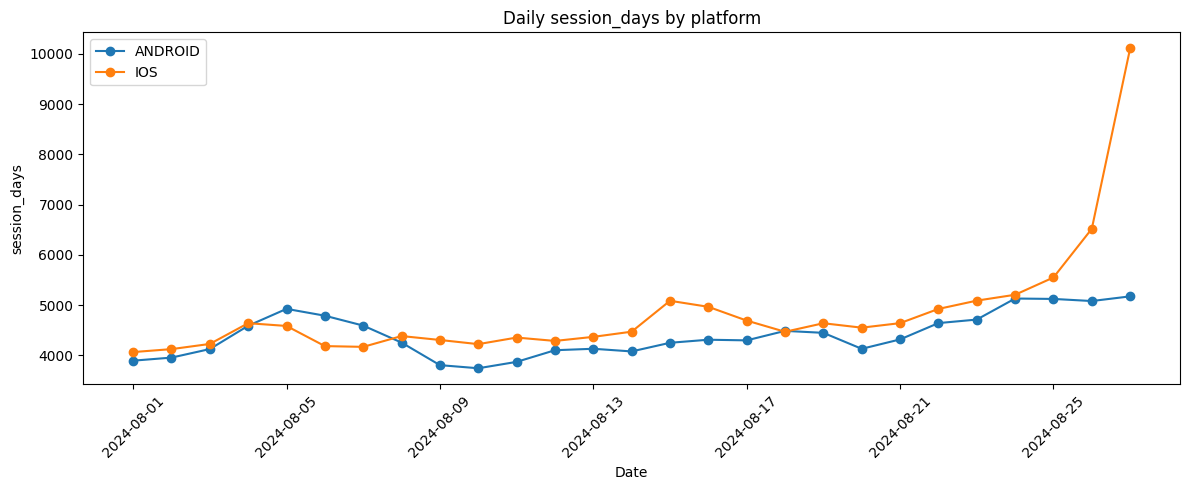

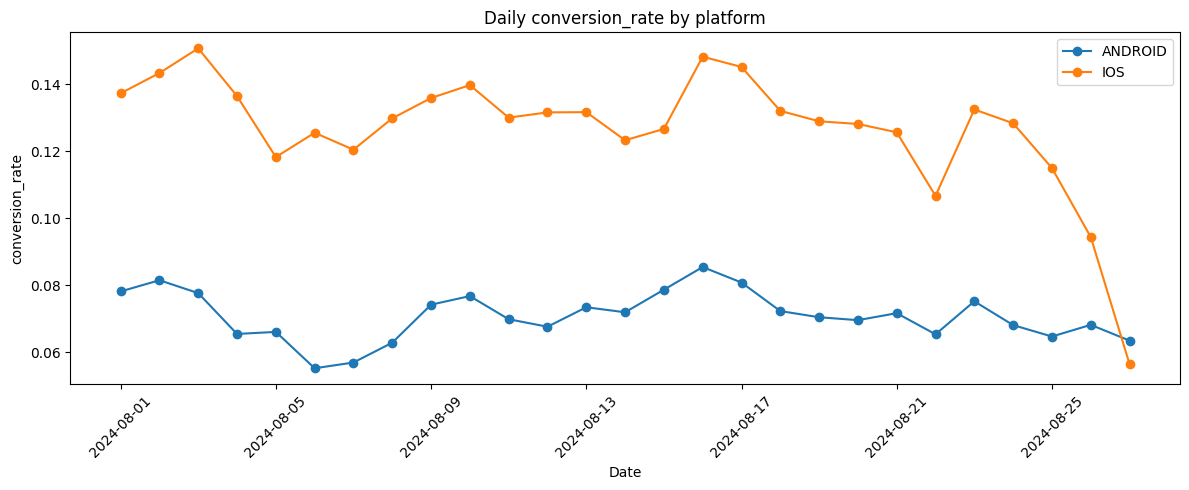

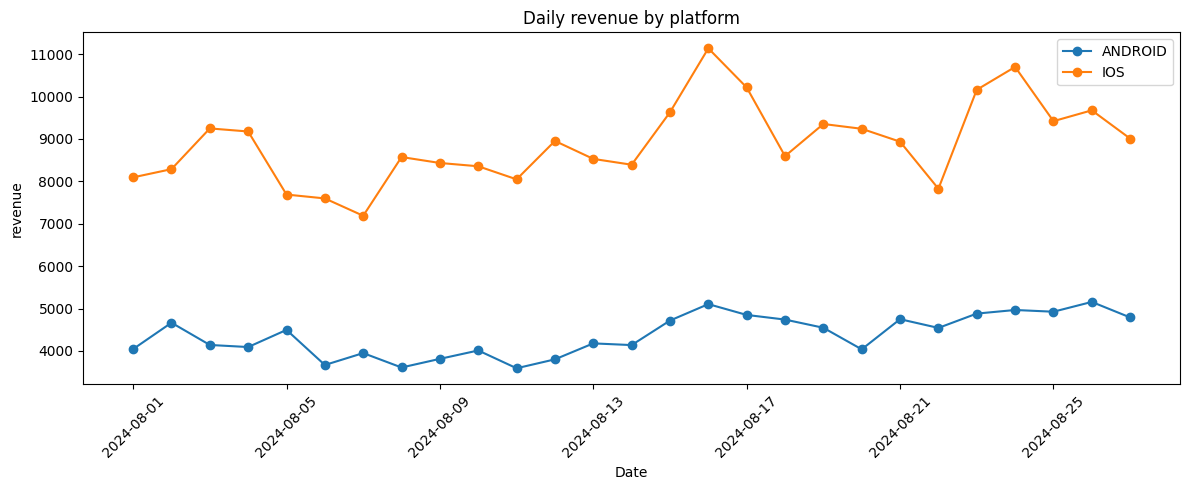

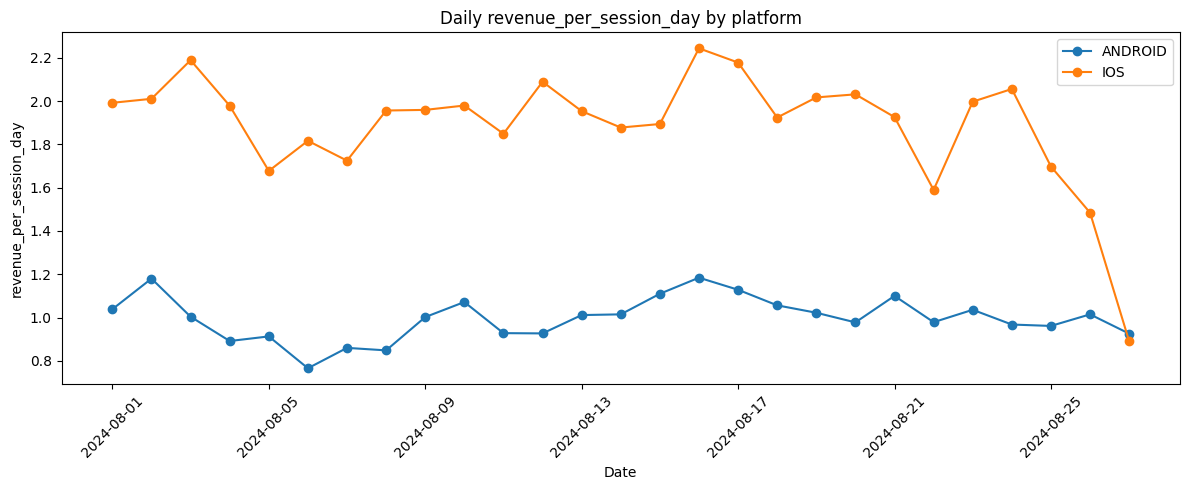

In [ ]:
for metric in ["session_days", "conversion_rate", "revenue", "revenue_per_session_day"]:
    plt.figure(figsize=(12, 5))

    for platform in daily_platform["platform"].unique():
        temp = daily_platform[daily_platform["platform"] == platform]
        plt.plot(temp["session_date"], temp[metric], marker="o", label=platform)

    plt.title(f"Daily {metric} by platform")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Anomaly detected: sudden iOS conversion-rate drop after 2024-08-22.

Initial country-mix view suggests:

- Morocco: traffic increased massively, and conversion rate dropped by about 7 percentage points. This is the strongest anomaly candidate.
- United States: traffic increased, but conversion barely changed, so it is not the main problem.
- Poland: conversion also dropped strongly, around 6 percentage points, but the traffic increase is much smaller than Morocco, so total impact is likely smaller.
- Canada / UK / Lithuania / Denmark: also show weaker conversion, but the real impact depends on session volume.

The next added table estimates the buyer and revenue gap by country. This is more useful than looking only at conversion-rate change.


In [ ]:
ios_geo_period = con.execute("""
WITH geo_period AS (
    SELECT
        CASE
            WHEN session_date < '2024-08-22' THEN 'before_2024_08_22'
            ELSE 'from_2024_08_22'
        END AS period,
        geo_country,
        COUNT(*) AS session_days,
        SUM(has_purchase) AS buyers,
        SUM(revenue) AS revenue,
        SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
        SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day
    FROM session_day
    WHERE platform = 'IOS'
    GROUP BY period, geo_country
)
SELECT *
FROM geo_period
ORDER BY period, session_days DESC
""").df()

ios_geo_period.head(15)

,period,geo_country,session_days,buyers,revenue,conversion_rate,revenue_per_session_day
0,before_2024_08_22,United States,30498,"3,760.0000","55,056.0800",0.1233,1.8052
1,before_2024_08_22,United Kingdom,25317,"2,464.0000","37,023.3900",0.0973,1.4624
2,before_2024_08_22,Canada,16384,"3,406.0000","53,938.9100",0.2079,3.2922
3,before_2024_08_22,Lithuania,2927,458.0000,"5,869.6300",0.1565,2.0053
4,before_2024_08_22,Morocco,2606,197.0000,"2,579.4500",0.0756,0.9898
5,before_2024_08_22,Poland,1875,238.0000,"3,046.6900",0.1269,1.6249
6,before_2024_08_22,South Africa,1870,237.0000,"3,143.9700",0.1267,1.6813
7,before_2024_08_22,Sweden,1343,165.0000,"2,304.4400",0.1229,1.7159
8,before_2024_08_22,Norway,1208,183.0000,"3,443.1800",0.1515,2.8503
9,before_2024_08_22,Egypt,1188,90.0000,"1,268.3900",0.0758,1.0677


In [42]:
ios_geo_daily_after_22 = con.execute("""
SELECT
    session_date,
    geo_country,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    SUM(revenue) AS revenue,
    SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
    SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day
FROM session_day
WHERE platform = 'IOS'
  AND session_date >= '2024-08-22'
GROUP BY session_date, geo_country
ORDER BY session_date, session_days DESC
""").df()

ios_geo_daily_after_22.head(15)

,session_date,geo_country,session_days,buyers,revenue,conversion_rate,revenue_per_session_day
0,2024-08-22,United States,1597,189.0000,"2,715.8700",0.1183,1.7006
1,2024-08-22,United Kingdom,1286,89.0000,"1,255.3400",0.0692,0.9762
2,2024-08-22,Canada,916,141.0000,"2,427.9300",0.1539,2.6506
3,2024-08-22,Poland,190,12.0000,136.5300,0.0632,0.7186
4,2024-08-22,Morocco,174,6.0000,44.9400,0.0345,0.2583
5,2024-08-22,Lithuania,150,21.0000,305.3400,0.1400,2.0356
6,2024-08-22,South Africa,67,8.0000,89.4200,0.1194,1.3346
7,2024-08-22,Sweden,67,4.0000,61.4600,0.0597,0.9173
8,2024-08-22,Ireland,64,5.0000,56.4500,0.0781,0.8820
9,2024-08-22,Romania,46,6.0000,54.5400,0.1304,1.1857


In [ ]:
ios_country_change = con.execute("""
WITH country_period AS (
    SELECT
        CASE
            WHEN session_date < '2024-08-22' THEN 'before'
            ELSE 'after'
        END AS period,
        geo_country,
        COUNT(DISTINCT session_date) AS active_dates,
        COUNT(*) AS session_days,
        SUM(has_purchase) AS buyers,
        SUM(revenue) AS revenue
    FROM session_day
    WHERE platform = 'IOS'
    GROUP BY period, geo_country
),

pivoted AS (
    SELECT
        geo_country,

        SUM(CASE WHEN period = 'before' THEN session_days ELSE 0 END) AS sessions_before,
        SUM(CASE WHEN period = 'after' THEN session_days ELSE 0 END) AS sessions_after,

        SUM(CASE WHEN period = 'before' THEN buyers ELSE 0 END) AS buyers_before,
        SUM(CASE WHEN period = 'after' THEN buyers ELSE 0 END) AS buyers_after,

        SUM(CASE WHEN period = 'before' THEN revenue ELSE 0 END) AS revenue_before,
        SUM(CASE WHEN period = 'after' THEN revenue ELSE 0 END) AS revenue_after,

        MAX(CASE WHEN period = 'before' THEN active_dates ELSE NULL END) AS days_before,
        MAX(CASE WHEN period = 'after' THEN active_dates ELSE NULL END) AS days_after
    FROM country_period
    GROUP BY geo_country
)
SELECT
    geo_country,
    sessions_before,
    sessions_after,
    sessions_before * 1.0 / NULLIF(days_before, 0) AS avg_daily_sessions_before,
    sessions_after * 1.0 / NULLIF(days_after, 0) AS avg_daily_sessions_after,
    buyers_before * 1.0 / NULLIF(sessions_before, 0) AS cr_before,
    buyers_after * 1.0 / NULLIF(sessions_after, 0) AS cr_after,
    revenue_before * 1.0 / NULLIF(sessions_before, 0) AS rps_before,
    revenue_after * 1.0 / NULLIF(sessions_after, 0) AS rps_after,
    (sessions_after * 1.0 / NULLIF(days_after, 0))
      - (sessions_before * 1.0 / NULLIF(days_before, 0)) AS avg_daily_session_change,
    (buyers_after * 1.0 / NULLIF(sessions_after, 0))
      - (buyers_before * 1.0 / NULLIF(sessions_before, 0)) AS cr_change
FROM pivoted
WHERE sessions_before >= 50
   OR sessions_after >= 50
ORDER BY avg_daily_session_change DESC
""").df()

ios_country_change.head(15)

,geo_country,sessions_before,sessions_after,avg_daily_sessions_before,avg_daily_sessions_after,cr_before,cr_after,rps_before,rps_after,avg_daily_session_change,cr_change
0,Morocco,"2,606.0000","7,632.0000",124.0952,"1,272.0000",0.0756,0.0048,0.9898,0.0558,"1,147.9048",-0.0707
1,United States,"30,498.0000","10,167.0000","1,452.2857","1,694.5000",0.1233,0.1239,1.8052,1.8804,242.2143,0.0006
2,Canada,"16,384.0000","5,572.0000",780.1905,928.6667,0.2079,0.1870,3.2922,3.1152,148.4762,-0.0209
3,United Kingdom,"25,317.0000","7,961.0000","1,205.5714","1,326.8333",0.0973,0.0868,1.4624,1.3142,121.2619,-0.0105
4,Poland,"1,875.0000",813.0000,89.2857,135.5000,0.1269,0.0689,1.6249,0.9354,46.2143,-0.0581
5,Lithuania,"2,927.0000","1,065.0000",139.3810,177.5000,0.1565,0.1127,2.0053,1.5108,38.1190,-0.0438
6,Ireland,"1,157.0000",396.0000,55.0952,66.0000,0.1469,0.1136,2.2574,1.5449,10.9048,-0.0333
7,Hungary,674.0000,229.0000,32.0952,38.1667,0.1469,0.1441,1.8511,3.4710,6.0714,-0.0028
8,Finland,343.0000,134.0000,16.3333,22.3333,0.1924,0.1940,2.9199,2.6581,6.0000,0.0016
9,Denmark,779.0000,255.0000,37.0952,42.5000,0.1694,0.1451,2.6257,2.2238,5.4048,-0.0243


### iOS anomaly contribution table

This estimates how many buyers were lost or gained after 2024-08-22 if each country had kept its earlier conversion rate.  
Negative `buyer_gap` means fewer buyers than expected from that country after the anomaly start.


In [ ]:
# Quantify anomaly contribution by country, not only conversion-rate movement.
ios_country_impact = con.execute("""
WITH country_period AS (
    SELECT
        CASE
            WHEN session_date < '2024-08-22' THEN 'before'
            ELSE 'after'
        END AS period,
        geo_country,
        COUNT(DISTINCT session_date) AS active_dates,
        COUNT(*) AS session_days,
        SUM(has_purchase) AS buyers,
        SUM(revenue) AS revenue
    FROM session_day
    WHERE platform = 'IOS'
    GROUP BY period, geo_country
),
pivoted AS (
    SELECT
        geo_country,

        SUM(CASE WHEN period = 'before' THEN session_days ELSE 0 END) AS sessions_before,
        SUM(CASE WHEN period = 'after' THEN session_days ELSE 0 END) AS sessions_after,

        SUM(CASE WHEN period = 'before' THEN buyers ELSE 0 END) AS buyers_before,
        SUM(CASE WHEN period = 'after' THEN buyers ELSE 0 END) AS buyers_after,

        SUM(CASE WHEN period = 'before' THEN revenue ELSE 0 END) AS revenue_before,
        SUM(CASE WHEN period = 'after' THEN revenue ELSE 0 END) AS revenue_after,

        MAX(CASE WHEN period = 'before' THEN active_dates ELSE NULL END) AS days_before,
        MAX(CASE WHEN period = 'after' THEN active_dates ELSE NULL END) AS days_after
    FROM country_period
    GROUP BY geo_country
)
SELECT
    geo_country,
    sessions_before,
    sessions_after,

    ROUND(sessions_before * 1.0 / NULLIF(days_before, 0), 2) AS avg_daily_sessions_before,
    ROUND(sessions_after * 1.0 / NULLIF(days_after, 0), 2) AS avg_daily_sessions_after,

    ROUND(buyers_before * 1.0 / NULLIF(sessions_before, 0), 4) AS cr_before,
    ROUND(buyers_after * 1.0 / NULLIF(sessions_after, 0), 4) AS cr_after,

    ROUND(sessions_after * (buyers_before * 1.0 / NULLIF(sessions_before, 0)), 2) AS expected_buyers_after_at_old_cr,
    buyers_after AS actual_buyers_after,

    ROUND(
        buyers_after - sessions_after * (buyers_before * 1.0 / NULLIF(sessions_before, 0)),
        2
    ) AS buyer_gap,

    ROUND(
        revenue_after - sessions_after * (revenue_before * 1.0 / NULLIF(sessions_before, 0)),
        2
    ) AS revenue_gap
FROM pivoted
WHERE sessions_before >= 50
  AND sessions_after >= 50
ORDER BY buyer_gap ASC
""").df()

display(ios_country_impact.head(15))

,geo_country,sessions_before,sessions_after,avg_daily_sessions_before,avg_daily_sessions_after,cr_before,cr_after,expected_buyers_after_at_old_cr,actual_buyers_after,buyer_gap,revenue_gap
0,Morocco,"2,606.0000","7,632.0000",124.1000,"1,272.0000",0.0756,0.0048,576.9400,37.0000,-539.9400,"-7,128.6300"
1,Canada,"16,384.0000","5,572.0000",780.1900,928.6700,0.2079,0.1870,"1,158.3400","1,042.0000",-116.3400,-986.2800
2,United Kingdom,"25,317.0000","7,961.0000","1,205.5700","1,326.8300",0.0973,0.0868,774.8100,691.0000,-83.8100,"-1,179.4900"
3,Poland,"1,875.0000",813.0000,89.2900,135.5000,0.1269,0.0689,103.2000,56.0000,-47.2000,-560.5700
4,Lithuania,"2,927.0000","1,065.0000",139.3800,177.5000,0.1565,0.1127,166.6500,120.0000,-46.6500,-526.6900
5,Ireland,"1,157.0000",396.0000,55.1000,66.0000,0.1469,0.1136,58.1800,45.0000,-13.1800,-282.1400
6,Czechia,889.0000,230.0000,42.3300,38.3300,0.1800,0.1261,41.3900,29.0000,-12.3900,-152.2500
7,Romania,"1,048.0000",289.0000,49.9000,48.1700,0.1469,0.1073,42.4700,31.0000,-11.4700,-204.0400
8,Tunisia,687.0000,184.0000,32.7100,30.6700,0.1368,0.0815,25.1800,15.0000,-10.1800,-153.2500
9,Sweden,"1,343.0000",392.0000,63.9500,65.3300,0.1229,0.0969,48.1600,38.0000,-10.1600,-185.1600


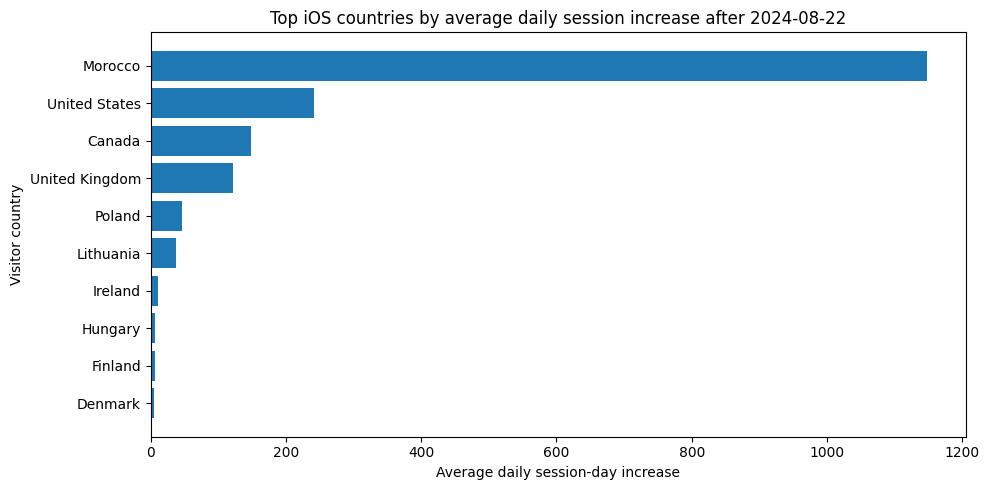

In [ ]:
top_movers = ios_country_change.sort_values(
    "avg_daily_session_change", ascending=False
).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_movers["geo_country"][::-1], top_movers["avg_daily_session_change"][::-1])
plt.title("Top iOS countries by average daily session increase after 2024-08-22")
plt.xlabel("Average daily session-day increase")
plt.ylabel("Visitor country")
plt.tight_layout()
plt.show()

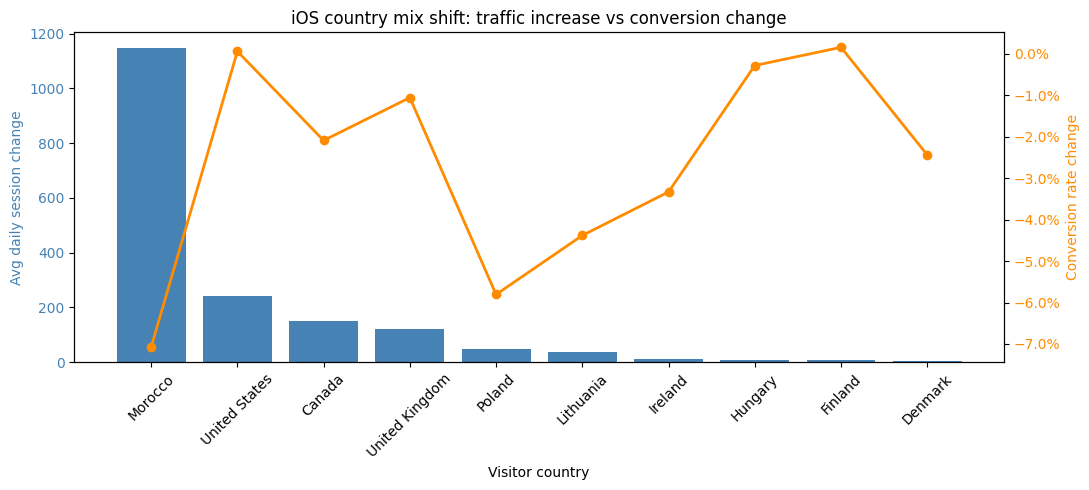

In [ ]:
top_movers = ios_country_change.sort_values(
    "avg_daily_session_change", ascending=False
).head(10)

bar_color = "steelblue"
line_color = "darkorange"
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(
    top_movers["geo_country"], top_movers["avg_daily_session_change"], color=bar_color
)
ax1.set_ylabel("Avg daily session change", color=bar_color)
ax1.set_xlabel("Visitor country")
ax1.tick_params(axis="y", labelcolor=bar_color)
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(
    top_movers["geo_country"],
    top_movers["cr_change"],
    marker="o",
    color=line_color,
    linewidth=2,
)
ax2.set_ylabel("Conversion rate change", color=line_color)
ax2.tick_params(axis="y", labelcolor=line_color)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("iOS country mix shift: traffic increase vs conversion change")
fig.tight_layout()
plt.show()

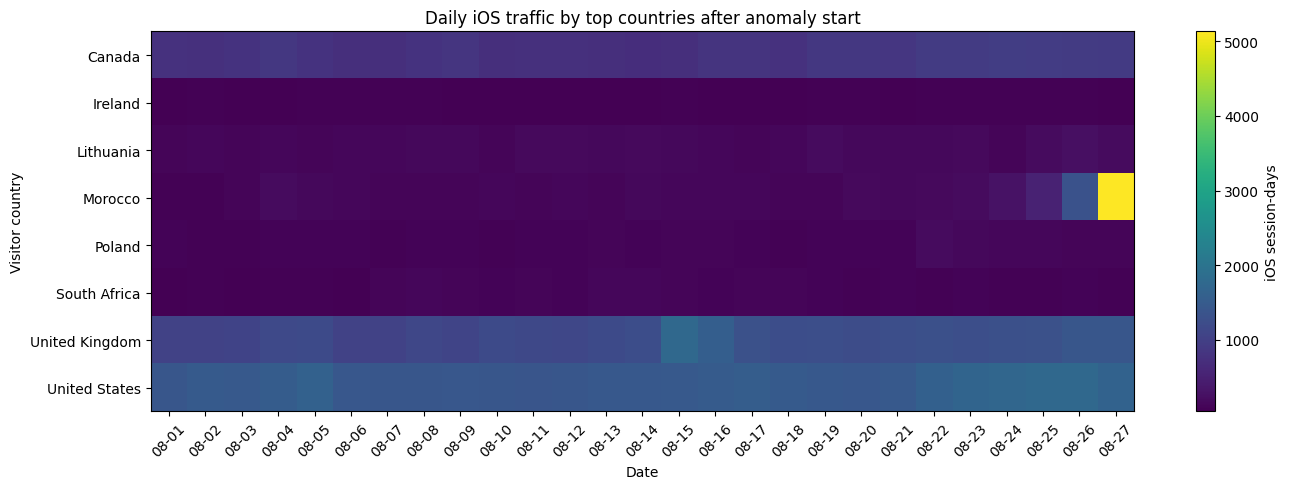

In [47]:
top_after_countries = con.execute("""
SELECT
    geo_country,
    COUNT(*) AS session_days
FROM session_day
WHERE platform = 'IOS'
  AND session_date >= '2024-08-22'
GROUP BY geo_country
ORDER BY session_days DESC
LIMIT 8
""").df()["geo_country"].tolist()

ios_country_daily = con.execute("""
SELECT
    session_date,
    geo_country,
    COUNT(*) AS session_days
FROM session_day
WHERE platform = 'IOS'
GROUP BY session_date, geo_country
ORDER BY session_date, geo_country
""").df()

heatmap_data = (
    ios_country_daily[ios_country_daily["geo_country"].isin(top_after_countries)]
    .pivot(index="geo_country", columns="session_date", values="session_days")
    .fillna(0)
)

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data, aspect="auto")

plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xticks(
    range(len(heatmap_data.columns)),
    [pd.to_datetime(x).strftime("%m-%d") for x in heatmap_data.columns],
    rotation=45,
)

plt.colorbar(label="iOS session-days")
plt.title("Daily iOS traffic by top countries after anomaly start")
plt.xlabel("Date")
plt.ylabel("Visitor country")
plt.tight_layout()
plt.show()

### 4. Event table understanding

- click_to_order_1 = earlier order intent, destination known
- click_to_order_2 = deeper order intent, destination + quota known


In [48]:
query = """
SELECT
    event_name,
    COUNT(*) AS event_rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids,
    COUNT(plan_destination) AS rows_with_destination,
    COUNT(plan_quota) AS rows_with_quota
FROM events
GROUP BY event_name
ORDER BY event_rows DESC
"""

event_summary = con.execute(query).df()
event_summary.head(15)

,event_name,event_rows,unique_session_ids,rows_with_destination,rows_with_quota
0,click_to_order_1,170437,115088,170436,0
1,click_to_order_2,82013,73420,82013,82013


### 5. Funnel analysis

Important: since `events` has no `session_date`, I do not join event flags directly to `session_day` for daily funnel analysis.  
Doing that would spread the same event across every active day of that `unique_session_id`.

Instead, I build a period-level funnel by `unique_session_id`. This is acceptable here because the extra stability check above shows that `platform`, `geo_country`, and `esim_compatible` do not conflict within the same `unique_session_id` across the period.

Because the events table has no timestamp and a small number of sessions have later funnel events without earlier ones, this funnel should be interpreted as an event-presence funnel rather than a perfectly ordered step-by-step funnel.


Creating a period-level purchase table.


In [ ]:
visitor_period = con.execute("""
SELECT
    unique_session_id,
    platform,
    geo_country,
    esim_compatible,
    COUNT(DISTINCT session_date) AS active_days,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,
    CASE
        WHEN COUNT(transaction_id) > 0 THEN 1
        ELSE 0
    END AS has_purchase,
    SUM(COALESCE(total_billings_in_usd, 0)) AS revenue
FROM sessions
GROUP BY
    unique_session_id,
    platform,
    geo_country,
    esim_compatible
""").df()

con.register("visitor_period", visitor_period)
visitor_period.head()

,unique_session_id,platform,geo_country,esim_compatible,active_days,transaction_rows,unique_transactions,has_purchase,revenue
0,1724331815-4ea3e13b83f8148f478c134f5a17e9b1,ANDROID,Canada,true,1,1,1,1,43.9900
1,1724328128-8360f2e5fa210b9a91a67b11b607f8ee,ANDROID,United States,true,1,0,0,0,0.0000
2,1724300849-58eb4f7d5dd7e0c1d9b707d14d7cd873,ANDROID,United States,true,1,0,0,0,0.0000
3,1724331089-d67a382feaaa3b7fae593dbaf5106ef1,ANDROID,Canada,true,1,0,0,0,0.0000
4,1724354128-b85948e192e1833d2e953947556c1a15,ANDROID,United Kingdom,true,1,0,0,0,0.0000


Creating event flags


In [ ]:
event_flags = con.execute("""
SELECT
    unique_session_id,
    MAX(CASE WHEN event_name = 'click_to_order_1' THEN 1 ELSE 0 END) AS has_click_to_order_1,
    MAX(CASE WHEN event_name = 'click_to_order_2' THEN 1 ELSE 0 END) AS has_click_to_order_2,
    COUNT(*) AS total_events
FROM events
GROUP BY unique_session_id
""").df()

con.register("event_flags", event_flags)
event_flags.head()

,unique_session_id,has_click_to_order_1,has_click_to_order_2,total_events
0,1724191796-84BA6E90F3734A2789500F5BA107B0CD,1,1,2
1,1724662334-030821B432FE48DA8F1F91D4D8BBAEF0,1,1,3
2,1724756204-c07a82e75d241a01933f74e87d0f5ae0,1,1,6
3,1723968956-035648dad35934f10468426d4987223c,1,1,4
4,1724343578-092a40f3404672f7526ba4fad7b6053d,1,1,2


### 6. Funnel with Android compatibility


In [ ]:
funnel_android_compat = con.execute("""
SELECT
    v.platform,
    v.esim_compatible,
    COUNT(*) AS visitors,
    SUM(COALESCE(e.has_click_to_order_1, 0)) AS click_to_order_1,
    SUM(COALESCE(e.has_click_to_order_2, 0)) AS click_to_order_2,
    SUM(v.has_purchase) AS buyers,
    SUM(COALESCE(e.has_click_to_order_1, 0)) * 1.0 / COUNT(*) AS visitor_to_click_1_rate,
    SUM(COALESCE(e.has_click_to_order_2, 0)) * 1.0 / NULLIF(SUM(COALESCE(e.has_click_to_order_1, 0)), 0) AS click_1_to_click_2_rate,
    SUM(v.has_purchase) * 1.0 / NULLIF(SUM(COALESCE(e.has_click_to_order_2, 0)), 0) AS click_2_to_purchase_rate,
    SUM(v.has_purchase) * 1.0 / COUNT(*) AS total_conversion_rate
FROM visitor_period v
LEFT JOIN event_flags e
    ON v.unique_session_id = e.unique_session_id
GROUP BY
    v.platform,
    v.esim_compatible
ORDER BY
    v.platform,
    v.esim_compatible
""").df()

funnel_android_compat

,platform,esim_compatible,visitors,click_to_order_1,click_to_order_2,buyers,visitor_to_click_1_rate,click_1_to_click_2_rate,click_2_to_purchase_rate,total_conversion_rate
0,ANDROID,false,27073,"7,889.0000","4,735.0000",110.0000,0.2914,0.6002,0.0232,0.0041
1,ANDROID,true,85603,"44,666.0000","25,273.0000","8,258.0000",0.5218,0.5658,0.3268,0.0965
2,IOS,not_applicable,128872,"62,532.0000","43,411.0000","16,088.0000",0.4852,0.6942,0.3706,0.1248


In [ ]:
transactions = con.execute("""
SELECT DISTINCT
    session_date,
    unique_session_id,
    platform,
    geo_country,
    esim_compatible,
    transaction_id,
    transaction_plan_destination,
    transaction_plan_quota,
    total_billings_in_usd AS revenue
FROM sessions
WHERE transaction_id IS NOT NULL
""").df()

con.register("transactions", transactions)
transactions.head()

,session_date,unique_session_id,platform,geo_country,esim_compatible,transaction_id,transaction_plan_destination,transaction_plan_quota,revenue
0,2024-08-22,1724281541-74e94da57077700d29aa3f858baa7a1a,ANDROID,United Kingdom,true,ebb5651e-ea02-41f3-8b20-cec575b467c3,UG,10.0000,35.6900
1,2024-08-22,1724335297-a11f09f6187c5efe3416913354059427,ANDROID,United States,true,74971bc5-e253-4283-a1d2-56935090401d,US,3.0000,8.9900
2,2024-08-22,1724314048-33672daec869f5ae6a6c56149865907c,ANDROID,United States,true,1ba8796e-97ba-43c4-9323-7ac01864e7ca,JP,20.0000,22.9900
3,2024-08-22,1724309638-28c0c59ff500a5cbda930c7b2cbd3613,ANDROID,United States,true,9f8b2c0f-20d0-403b-919c-74f025529d9f,SV,3.0000,17.9900
4,2024-08-22,1724325512-4902e525e725751f7e635b4d57ad57a5,ANDROID,United States,false,b3ae874d-d5b0-479e-b81e-3c07b9c4f0b6,US,1.0000,3.9900


In [ ]:
destination_mix = con.execute("""
SELECT
    platform,
    transaction_plan_destination AS destination,
    COUNT(*) AS transactions,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(AVG(revenue), 2) AS avg_revenue_per_transaction,
    ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY platform), 4) AS transaction_share,
    ROUND(SUM(revenue) * 1.0 / SUM(SUM(revenue)) OVER (PARTITION BY platform), 4) AS revenue_share
FROM transactions
GROUP BY
    platform,
    transaction_plan_destination
ORDER BY
    platform,
    revenue DESC
""").df()

destination_mix.head(15)
destination_mix.tail(15)

,platform,destination,transactions,revenue,avg_revenue_per_transaction,transaction_share,revenue_share
276,IOS,UZ,3,23.9700,7.9900,0.0002,0.0001
277,IOS,TG,1,22.9900,22.9900,0.0001,0.0001
278,IOS,MS,1,21.9900,21.9900,0.0001,0.0001
279,IOS,RE,2,20.3800,10.1900,0.0001,0.0001
280,IOS,GA,2,18.2800,9.1400,0.0001,0.0001
281,IOS,MN,3,17.0700,5.6900,0.0002,0.0001
282,IOS,DM,1,16.9900,16.9900,0.0001,0.0001
283,IOS,WS,1,14.9900,14.9900,0.0001,0.0001
284,IOS,AD,2,13.9800,6.9900,0.0001,0.0001
285,IOS,AM,2,11.5800,5.7900,0.0001,0.0000


Plan quota mix is broadly similar between Android and iOS, so the platform revenue gap does not appear to be mainly explained by iOS users buying much larger plans.  
Instead, the bigger driver is conversion.

Destination analysis shows that the US is the largest revenue-generating purchased destination on both platforms, with iOS generating substantially more revenue.  
This suggests iOS outperformance is not isolated to one minor plan type, but visible across key destinations.


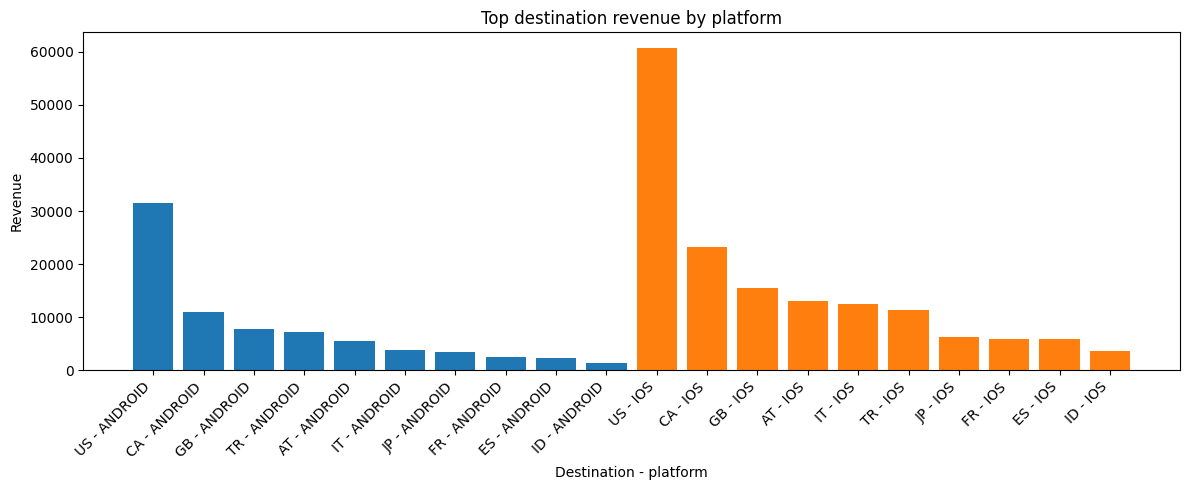

In [54]:
top_destinations = (
    destination_mix.groupby("destination")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_data = destination_mix[destination_mix["destination"].isin(top_destinations)]

plt.figure(figsize=(12, 5))

for platform in plot_data["platform"].unique():
    temp = plot_data[plot_data["platform"] == platform]
    plt.bar(temp["destination"] + " - " + platform, temp["revenue"])

plt.title("Top destination revenue by platform")
plt.xlabel("Destination - platform")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
quota_mix = con.execute("""
SELECT
    platform,
    transaction_plan_quota AS quota_gb,
    COUNT(*) AS transactions,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(AVG(revenue), 2) AS avg_revenue_per_transaction,
    ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY platform), 4) AS transaction_share,
    ROUND(SUM(revenue) * 1.0 / SUM(SUM(revenue)) OVER (PARTITION BY platform), 4) AS revenue_share
FROM transactions
GROUP BY
    platform,
    transaction_plan_quota
ORDER BY
    platform,
    quota_gb
""").df()

quota_mix

,platform,quota_gb,transactions,revenue,avg_revenue_per_transaction,transaction_share,revenue_share
0,ANDROID,1.0000,2251,"10,040.2600",4.4600,0.2616,0.0850
1,ANDROID,2.0000,12,181.6600,15.1400,0.0014,0.0015
2,ANDROID,3.0000,1925,"18,178.3100",9.4400,0.2237,0.1538
3,ANDROID,5.0000,1850,"25,005.1200",13.5200,0.2150,0.2116
4,ANDROID,10.0000,1381,"29,576.4900",21.4200,0.1605,0.2503
5,ANDROID,20.0000,1176,"33,952.7200",28.8700,0.1366,0.2873
6,ANDROID,50.0000,8,736.1200,92.0200,0.0009,0.0062
7,ANDROID,100.0000,3,512.9700,170.9900,0.0003,0.0043
8,IOS,1.0000,3812,"16,923.8800",4.4400,0.2307,0.0704
9,IOS,2.0000,7,110.4300,15.7800,0.0004,0.0005


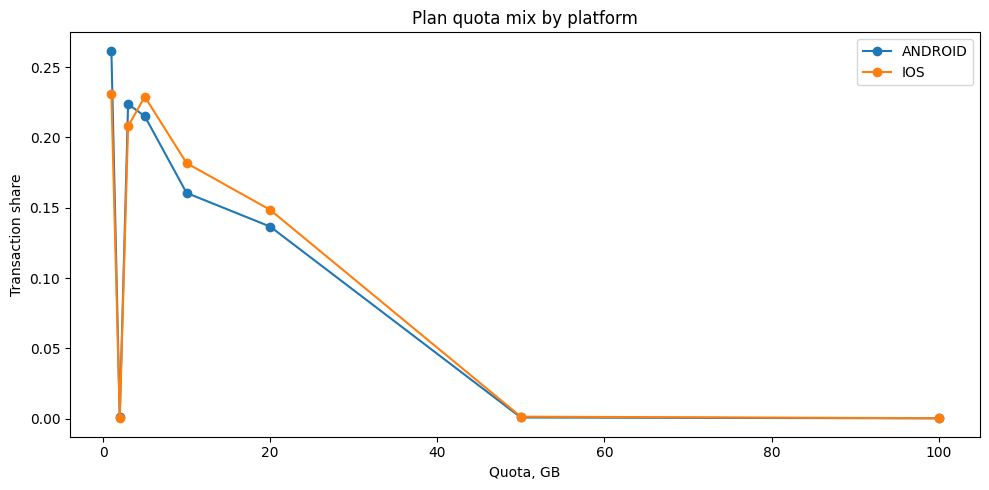

In [56]:
plt.figure(figsize=(10, 5))

for platform in quota_mix["platform"].unique():
    temp = quota_mix[quota_mix["platform"] == platform]
    plt.plot(temp["quota_gb"], temp["transaction_share"], marker="o", label=platform)

plt.title("Plan quota mix by platform")
plt.xlabel("Quota, GB")
plt.ylabel("Transaction share")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
decomposition = con.execute("""
SELECT
    platform,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(has_purchase) * 1.0 / COUNT(*), 4) AS conversion_rate,
    ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(has_purchase), 0), 2) AS revenue_per_buyer,
    ROUND(SUM(revenue) * 1.0 / COUNT(*), 2) AS revenue_per_session_day
FROM session_day
GROUP BY platform
ORDER BY revenue DESC
""").df()

decomposition

,platform,session_days,buyers,revenue,conversion_rate,revenue_per_buyer,revenue_per_session_day
0,IOS,130776,"16,093.0000","240,442.2000",0.1231,14.9400,1.8400
1,ANDROID,118902,"8,368.0000","118,183.6500",0.0704,14.1200,0.9900


### Conclusions

1. iOS wins, but not mainly because buyers spend more.
   - iOS performs better than Android mainly because of higher conversion rate.  
     Revenue per buyer is quite similar between iOS and Android-compatible users, so the main gap is conversion, not buyer spending.
2. Android compatibility is a major cause.
   - Android should not be evaluated as one single group.  
     Non-compatible Android devices have almost no conversion, which materially lowers Android's overall performance.  
     After separating compatible Android users, the platform gap becomes smaller, although iOS still remains stronger.
3. Funnel insight.
   - Android-compatible users are actually more likely than iOS users to reach the first order click, but they drop more heavily between `click_to_order_1` and `click_to_order_2`, and again before purchase.  
     This suggests Android’s issue may be in plan selection, compatibility communication, checkout UX, payment, or technical friction not lack of initial intent.
4. Incompatible Android users still reach order steps.
   - Although Android users are informed about compatibility, a meaningful share of non-compatible users still reach order-related events.  
     This may indicate that the compatibility warning is not sufficiently early, visible, or well understood.
5. Anomaly: iOS spike/crash.
   - The main iOS anomaly starts around 2024-08-22.  
     The last day, 2024-08-27, is the strongest outlier because traffic spikes while conversion and revenue per session fall sharply.  
     Country-level impact analysis points especially to Morocco as a major contributor, but the broader decline should also be checked against campaign changes, app releases, tracking issues, pricing changes, and payment/checkout problems.


### Final recommendations and additional data

| Finding                                                     | Recommended action                                                                                                                      |
| ----------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| Android-incompatible users still reach order-related events | Move the compatibility warning earlier and make it harder to miss. Track whether users understood the warning.                          |
| Android-compatible users drop after first order click       | Inspect Android plan-selection screen, checkout flow, payment errors, app version, and device model breakdown.                          |
| iOS conversion drops after 2024-08-22                       | Check marketing campaign/source mix, app release dates, tracking changes, pricing changes, and payment provider logs for this period.   |
| Morocco drives a large part of the iOS anomaly              | Validate whether Morocco traffic was paid, organic, bot/internal, misattributed, or affected by a country-specific offer/pricing issue. |
| iOS still converts better than Android-compatible users     | Use Android-specific diagnostics before treating this as a general platform preference.                                                 |

Additional data that would improve the analysis:

- traffic source / campaign / channel;
- app version and OS version;
- device model, especially for Android compatibility;
- event timestamp, not only event name;
- checkout/payment error reason;
- price shown to the customer;
- user type: new vs returning;
- refund/cancellation data;
- whether the compatibility warning was seen, clicked, or dismissed.
